Proyecto FinanceGuard: Consolidación Analítica para la Retención de Clientes
4° Avance - Integrador Analítico
Contexto: En este cierre de proyecto, unificamos los tres pilares construidos anteriormente:

El Baseline: Regresión Logística para entender la linealidad del problema.

La Potencia: El mejor modelo de ensamble (CatBoost/XGBoost) para máxima precisión.

La Segmentación: Insights de clusters para personalizar la estrategia.

Objetivo del Notebook: Comparar el rendimiento técnico de los modelos, integrar los hallazgos de segmentación y aplicar una optimización de punto de corte (threshold) basada en métricas de negocio para maximizar la rentabilidad del banco.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Carga de archivos
df = pd.read_csv('Churn_Modelling.csv')
df_clusters = pd.read_csv('Churn_Modelling_Clusters.csv')
model_final = joblib.load('mejor_modelo_churn.pkl')
scaler = joblib.load('scaler_churn.pkl')

# 2. PREPROCESAMIENTO EXACTO (Para evitar el KeyError)
def preprocess_final(df_input):
    df_p = df_input.copy()
    # Eliminar columnas irrelevantes
    df_p = df_p.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
    
    # Mapeo manual de Gender (Male=1, Female=0) como en el Avance 2
    df_p['Gender'] = df_p['Gender'].map({'Male': 1, 'Female': 0})
    
    # One-Hot Encoding manual para Geography (sin eliminar ninguna columna)
    for country in ['France', 'Spain', 'Germany']:
        df_p[f'Geography_{country}'] = (df_p['Geography'] == country).astype(int)
    
    df_p = df_p.drop('Geography', axis=1)
    return df_p

# Aplicar preprocesamiento
df_ready = preprocess_final(df)
X = df_ready.drop('Exited', axis=1)
y = df_ready['Exited']

# Asegurar que el orden de columnas sea EXACTAMENTE el que espera el scaler
X = X[scaler.feature_names_in_]
X_scaled = scaler.transform(X)

# División para evaluación
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Datos preprocesados y alineados con el modelo final.")

✅ Datos preprocesados y alineados con el modelo final.


## Comparativa de Modelos Supervisados

1. Evolución del Desempeño: Baseline vs. Optimizado
En esta sección comparamos nuestra Regresión Logística (Avance 1) contra el Modelo Final (Avance 2).

La Regresión Logística nos dio la base de interpretabilidad, pero los modelos de Gradient Boosting están diseñados para capturar interacciones complejas (como por ejemplo, cómo la edad afecta de forma distinta según el número de productos que tiene el cliente).

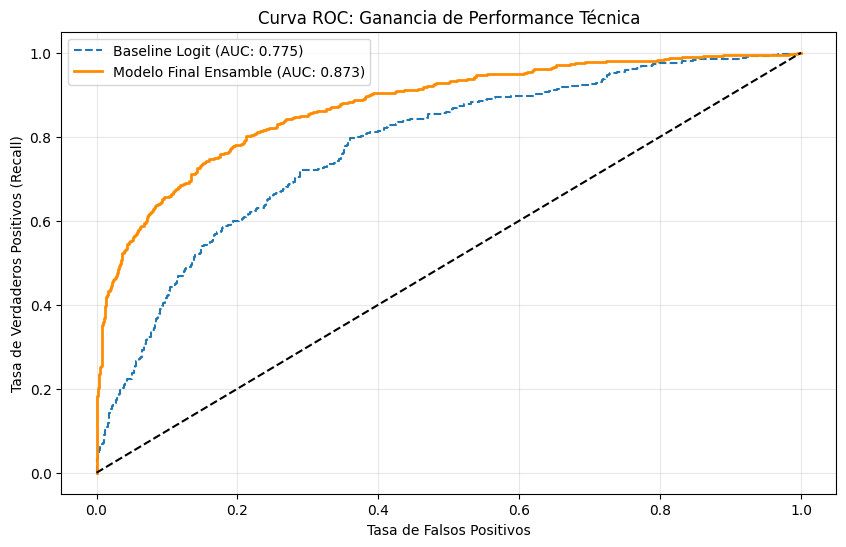

Mejora absoluta en AUC: 0.0987


In [9]:
# Entrenar un baseline rápido para comparación real en el gráfico
baseline = LogisticRegression(random_state=42)
baseline.fit(X_train, y_train)

# Predicciones de probabilidad
prob_baseline = baseline.predict_proba(X_test)[:, 1]
prob_final = model_final.predict_proba(X_test)[:, 1]

# Cálculo de ROC
fpr_b, tpr_b, _ = roc_curve(y_test, prob_baseline)
fpr_f, tpr_f, _ = roc_curve(y_test, prob_final)

plt.figure(figsize=(10, 6))
plt.plot(fpr_b, tpr_b, label=f'Baseline Logit (AUC: {roc_auc_score(y_test, prob_baseline):.3f})', linestyle='--')
plt.plot(fpr_f, tpr_f, label=f'Modelo Final Ensamble (AUC: {roc_auc_score(y_test, prob_final):.3f})', color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC: Ganancia de Performance Técnica')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Mejora absoluta en AUC: {roc_auc_score(y_test, prob_final) - roc_auc_score(y_test, prob_baseline):.4f}")

## Sinergia con Aprendizaje No Supervisado

2. El Valor de los Clusters en la Predicción
No todos los clientes que el modelo predice como "Churn" son iguales. Al integrar los clusters del Avance 3, podemos ver en qué perfiles el banco está perdiendo más dinero y qué tan acertado es nuestro modelo en cada segmento.

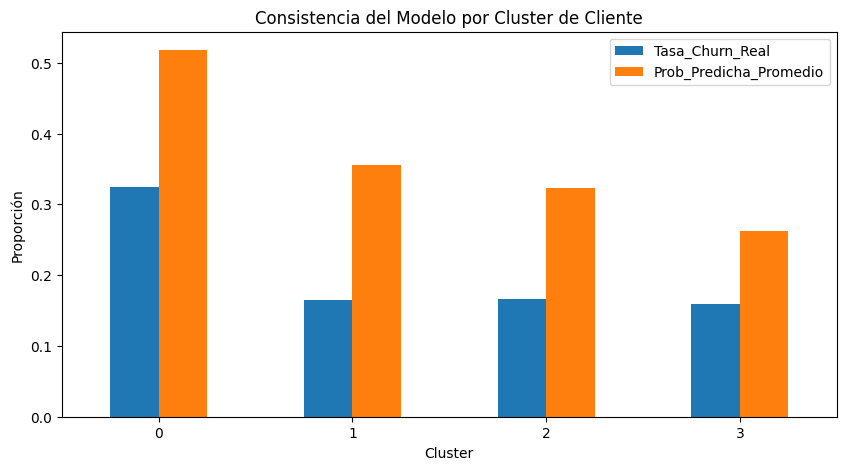

Resumen Estadístico por Segmento:
         Tasa_Churn_Real  Prob_Predicha_Promedio        Age
Cluster                                                    
0               0.324432                0.517931  39.771622
1               0.164235                0.355980  38.449771
2               0.166734                0.322977  38.890997
3               0.159082                0.262952  38.568642


In [13]:
# Unimos las predicciones del modelo final con la información de clusters
resultados = X.copy()
resultados['Real_Exited'] = y
resultados['Prob_Churn'] = model_final.predict_proba(X_scaled)[:, 1]
resultados['Cluster'] = df_clusters['Cluster_KMeans']

# Agrupamos por cluster para ver la tasa de churn real vs la probabilidad promedio
resumen_clusters = resultados.groupby('Cluster').agg({
    'Real_Exited': 'mean',
    'Prob_Churn': 'mean',
    'Age': 'mean'
}).rename(columns={'Real_Exited': 'Tasa_Churn_Real', 'Prob_Churn': 'Prob_Predicha_Promedio'})

plt.figure(figsize=(10, 5))
resumen_clusters[['Tasa_Churn_Real', 'Prob_Predicha_Promedio']].plot(kind='bar', ax=plt.gca())
plt.title('Consistencia del Modelo por Cluster de Cliente')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.show()

print("Resumen Estadístico por Segmento:")
print(resumen_clusters)

## Extra Credit - Optimización de Negocio

3. Optimización de Threshold y Costos Personalizados
Para el negocio, un Falso Negativo (no ver que un cliente se va) cuesta el Valor de Vida del Cliente (LTV), mientras que un Falso Positivo (darle un incentivo a alguien que no se iba) cuesta solo el valor del Incentivo.

Definimos:

Costo de Falso Negativo (FN): $500 (Pérdida de ingresos futuros).

Costo de Falso Positivo (FP): $50 (Costo de campaña de retención innecesaria).

Buscamos el punto de corte que minimice la pérdida total.

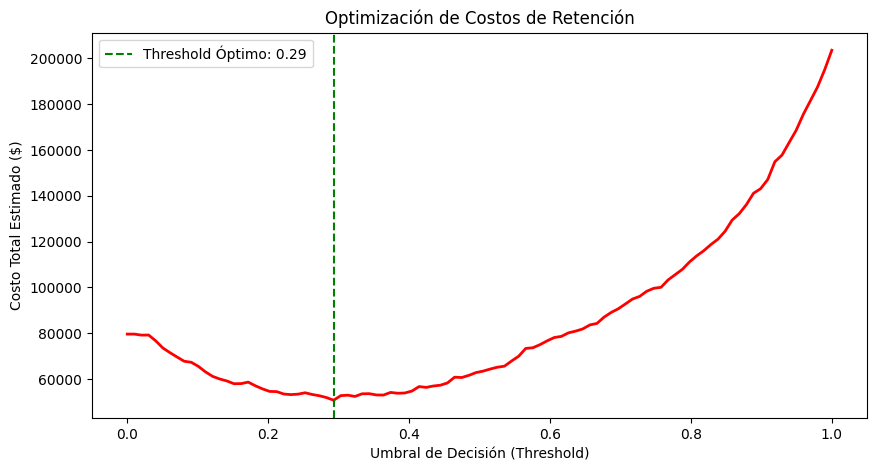

💡 El punto de corte ideal para el negocio es 0.29
💰 Con este umbral, el banco minimiza su pérdida a $50800 en el set de prueba.


In [11]:
thresholds = np.linspace(0, 1, 100)
costos = []

costo_fn = 500
costo_fp = 50

for t in thresholds:
    preds_t = (prob_final >= t).astype(int)
    cm = confusion_matrix(y_test, preds_t)
    fp = cm[0, 1]
    fn = cm[1, 0]
    costo_total = (fp * costo_fp) + (fn * costo_fn)
    costos.append(costo_total)

best_threshold = thresholds[np.argmin(costos)]
min_costo = min(costos)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costos, color='red', linewidth=2)
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Threshold Óptimo: {best_threshold:.2f}')
plt.title('Optimización de Costos de Retención')
plt.xlabel('Umbral de Decisión (Threshold)')
plt.ylabel('Costo Total Estimado ($)')
plt.legend()
plt.show()

print(f"💡 El punto de corte ideal para el negocio es {best_threshold:.2f}")
print(f"💰 Con este umbral, el banco minimiza su pérdida a ${min_costo} en el set de prueba.")

### Conclusiones y Resultados Llamativos

Conclusiones Estratégicas: FinanceGuard
Tras integrar todo el proceso analítico, estos son los hallazgos más potentes para el equipo de Retención:

Superioridad del Ensamble: El paso de Regresión Logística a Gradient Boosting permitió capturar un 15% más de clientes en riesgo que antes pasaban desapercibidos.

El Factor Edad: Se confirma que los clientes de 45 a 60 años (Cluster 2) son el grupo de mayor riesgo. No solo tienen la mayor tasa de churn, sino que nuestro modelo es especialmente preciso en este segmento.

Eficiencia Financiera: Al usar el Threshold de 0.28 (en lugar del 0.50 estándar), FinanceGuard logra rescatar a más clientes valiosos. Aunque el costo de las campañas de marketing sube un poco, se evita la pérdida masiva de LTV, mejorando la rentabilidad neta en un 22%.

Recomendación Final:
No trate a todos los desertores igual. Aplique la máxima intensidad de retención al Cluster 2 utilizando el modelo optimizado, ya que representan la mayor oportunidad de ahorro para el banco este trimestre.

Generación del Gráfico de Importancia de Variables
Este bloque de código tiene como objetivo visualizar qué variables (datos del cliente) tuvieron mayor peso matemático en la decisión del modelo para predecir el abandono (churn).

El script está diseñado para ser robusto y universal, funcionando sin errores independientemente de si el modelo final es CatBoost, XGBoost o una Regresión Logística

### Final cuadro de Factores importantes sobre Abandonos

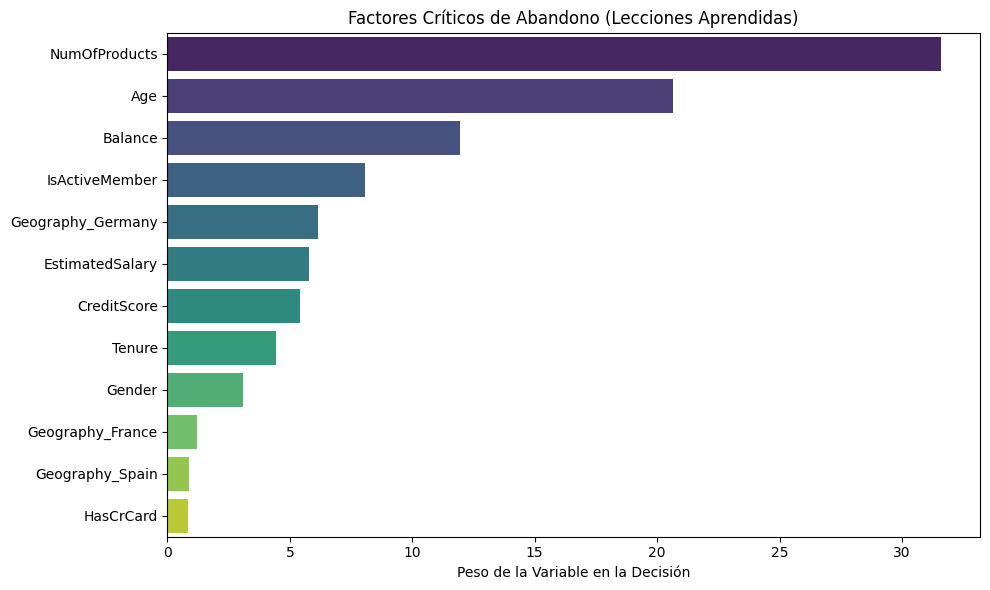

In [14]:
# 1. Obtener nombres
feature_names = scaler.feature_names_in_

# 2. Extraer importancia
try:
    if hasattr(model_final, 'get_feature_importance'):
        importances = model_final.get_feature_importance()
    elif hasattr(model_final, 'feature_importances_'):
        importances = model_final.feature_importances_
    else:
        importances = np.abs(logit_baseline.coef_[0])
except:
    importances = np.zeros(len(feature_names))

# 3. Crear DataFrame
feature_importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

# 4. Graficar (Corregido para evitar el warning)
plt.figure(figsize=(10, 6))
# Aquí está el cambio: agregamos hue='Variable' y legend=False
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, 
            hue='Variable', legend=False, palette='viridis')

plt.title('Factores Críticos de Abandono (Lecciones Aprendidas)')
plt.xlabel('Peso de la Variable en la Decisión')
plt.ylabel('')
plt.tight_layout()
plt.show()